In [38]:
import pandas as pd
import numpy as np
from pmdarima import ARIMA, auto_arima
from src.common.utils import get_root_directory
from src.common.stats import adf_test, pp_test
import matplotlib.pyplot as plt
import numpy as np
from src.preprocessing.data_loader import DataLoader
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import mlflow

In [39]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
DL.set_time_range(start_date="01/01/2022", end_date="31/12/2023")
train, test = DL.data_split(split_size=0.15)
test = test["ETH_D_AvgPrc"]
train, val = DL.data_split(split_type="train_val",split_size=0.15)
train = train["ETH_D_AvgPrc"]
val = val["ETH_D_AvgPrc"]

C:\Users\rajdh\Desktop\ETH_Price_Predition\src\preprocessing\data_loader.py:97: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  end_date = pd.to_datetime(end_date)


In [18]:
adf_result = adf_test(train)
pp_result = pp_test(train)

In [19]:
print(f"Is time series based on ADF test is stationary: {adf_result.is_stationary}.")
print(f"Is time series based on PP test is stationary: {pp_result.is_stationary}.")

Is time series based on ADF test is stationary: False.
Is time series based on PP test is stationary: False.


In [20]:
 def make_stationary(df, alpha: float = 0.05, max_diffs: int = 5) -> None:
    """
    Iterates through each column in a DataFrame and differences it until it
    becomes stationary based on the Augmented Dickey-Fuller (ADF) test.

    Parameters:
        alpha: Significance level for the ADF test (default 0.05).
        max_diffs: Maximum number of differences to apply (default 5).

    Returns:
        None
    """
    diff_counts = {}

    for col in df.columns:
        series = df[col].dropna()
        diff_count = 0

        while diff_count < max_diffs:
            stationarity_result = adf_test(series)

            if stationarity_result.is_stationary:
                break
            series = series.diff().dropna()
            diff_count += 1

        df[col] = series
        diff_counts[col] = diff_count
        return df, diff_counts

In [21]:
train_diff, diff_counts = make_stationary(pd.DataFrame(train))

In [22]:
train_diff = train_diff.dropna()

In [23]:
adf_result = adf_test(train_diff)
pp_result = pp_test(train_diff)
print(f"Is time series based on ADF test is stationary: {adf_result.is_stationary}.")
print(f"Is time series based on PP test is stationary: {pp_result.is_stationary}.")
print(f"The value of d in Arima should be {diff_counts}")

Is time series based on ADF test is stationary: True.
Is time series based on PP test is stationary: True.
The value of d in Arima should be {'ETH_D_AvgPrc': 1}


In [24]:
train_log = np.log(train)

In [25]:
adf_result = adf_test(train_log)
pp_result = pp_test(train_log)
print(f"Is time series based on ADF test is stationary: {adf_result.is_stationary}.")
print(f"Is time series based on PP test is stationary: {pp_result.is_stationary}.")

Is time series based on ADF test is stationary: False.
Is time series based on PP test is stationary: False.


In [26]:
train_diff, diff_counts = make_stationary(pd.DataFrame(train_log))
train_diff = train_diff.dropna()
adf_result = adf_test(train_diff)
pp_result = pp_test(train_diff)
print(f"Is time series based on ADF test is stationary: {adf_result.is_stationary}.")
print(f"Is time series based on PP test is stationary: {pp_result.is_stationary}.")
print(f"The value of d in Arima should be {diff_counts}")

Is time series based on ADF test is stationary: True.
Is time series based on PP test is stationary: True.
The value of d in Arima should be {'ETH_D_AvgPrc': 1}


In [27]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

def plot_acf_pacf(series, lags=20):
    """
    Plot ACF and PACF graphs for a given time series.

    :param series: Pandas Series containing time series data.
    :param lags: Number of lags to display in the plots (default is 20).
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot ACF (for q selection in ARIMA)
    sm.graphics.tsa.plot_acf(series, lags=lags, ax=axes[0])
    axes[0].set_title("Autocorrelation Function (ACF)")

    # Plot PACF (for p selection in ARIMA)
    sm.graphics.tsa.plot_pacf(series, lags=lags, ax=axes[1])
    axes[1].set_title("Partial Autocorrelation Function (PACF)")

    plt.tight_layout()
    plt.show()

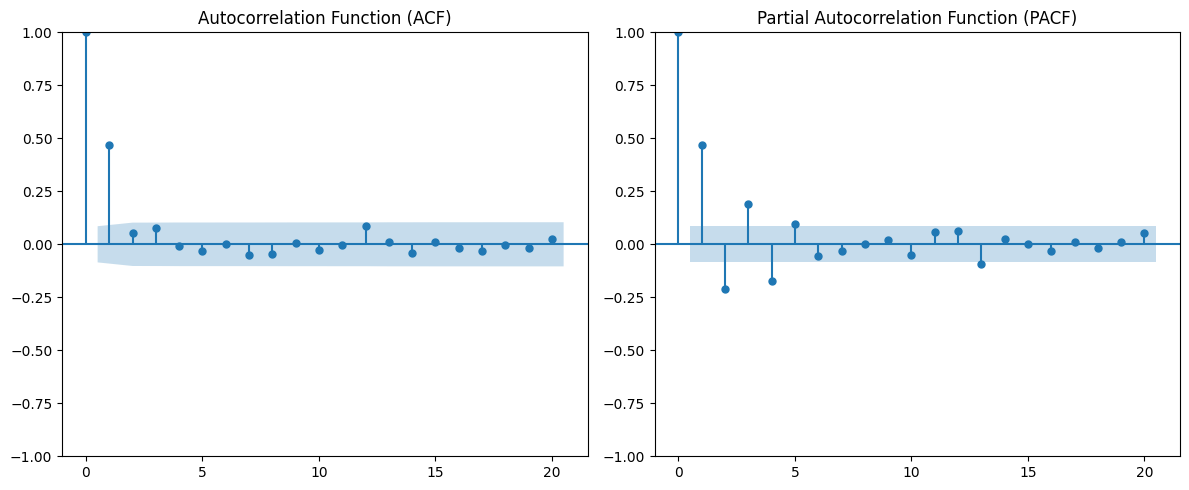

In [132]:
plot_acf_pacf(train_diff)

In [28]:
def collate_array_elements(arrays):
    if not arrays:
        return []
    return [list(group) for group in zip(*arrays)]

In [30]:
results = []
maxiter=500
n_periods=10
experiment_name = "ARIMA_train_validation"
mlflow.set_tracking_uri(f"sqlite:///{root_dir}/mlruns/mlruns.db")
mlflow.set_experiment(experiment_name)
log_transform = True

for p in range(1,7):
    for q in range(1,7):
        predictions = []
        if log_transform is True:
            val_gapped = np.log(val[:-10])
            train_recursive = list(np.log(list(train)))
        else:
            val_gapped = val[:-10]
            train_recursive = list(train)
        d =1
        order = (p, d, q)
        with mlflow.start_run(run_name=f"order_({p},{d},{q})"):
            model = ARIMA(maxiter=maxiter, order=order)
            for t in range(len(val_gapped)):
                model.fit(train_recursive)
                forecast = model.predict(n_periods=n_periods)
                predictions.append(forecast)
                train_recursive.append(val_gapped.iloc[t])
            mse_list = []
            rmse_list = []
            mae_list = []
            mape_list = []
            transposed = collate_array_elements(predictions)
            if log_transform is True:
                transposed = np.exp(transposed)
            for i in range(len(transposed)):
                mse = mean_squared_error(val[i:-10+i], transposed[i])
                rmse = root_mean_squared_error(val[i:-10+i], transposed[i])
                mae = mean_absolute_error(val[i:-10+i], transposed[i])
                mape = mean_absolute_percentage_error(val[i:-10+i], transposed[i])
                mse_list.append(mse)
                rmse_list.append(rmse)
                mae_list.append(mae)
                mape_list.append(mape)
            avg_mse = sum(mse_list)/len(mse_list)
            avg_rmse = sum(rmse_list)/len(rmse_list)
            avg_mae = sum(mae_list)/len(mae_list)
            avg_mape = sum(mape_list)/len(mape_list)
            mlflow.log_param("log_transform", log_transform)
            mlflow.log_param("p", p)
            mlflow.log_param("d", d)
            mlflow.log_param("q", q)
            mlflow.log_param("maxiter", maxiter)
            mlflow.log_param("n_periods", n_periods)
            mlflow.log_metric("avg_mse", avg_mse)
            mlflow.log_metric("avg_rmse", avg_rmse)
            mlflow.log_metric("avg_mae", avg_mae)
            mlflow.log_metric("avg_mape", avg_mape)
            results.append({"order": order, "avg_mse":avg_mse, "avg_rmse":avg_rmse, "avg_mae": avg_mae, "avg_mape":avg_mape})
    print(f"Completed order: {order}")
    mlflow.end_run()

C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\U

Completed order: (1, 1, 6)


C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\U

Completed order: (2, 1, 6)


C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\U

...

Completed order: (4, 1, 6)


C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\U

Completed order: (5, 1, 6)


C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\U

Completed order: (6, 1, 6)


In [41]:
experiment_name = "ARIMA_train_test"
mlflow.set_tracking_uri(f"sqlite:///{root_dir}/mlruns/mlruns.db")
mlflow.set_experiment(experiment_name)
log_transform = True
test_gapped = test[:-10]
train_recursive = list(train)
train_recursive.extend(list(val))
predictions = []
if log_transform is True:
    test_gapped = np.log(test[:-10])
    train_recursive = list(np.log(train_recursive))
order = (4, 1, 6)
p,d,q=order
model = ARIMA(maxiter=500, order=order)
mse_list = []
rmse_list = []
mae_list = []
mape_list = []
with mlflow.start_run(run_name=f"order_({p},{d},{q})"):
    for t in range(len(test_gapped)):
        model.fit(train_recursive)
        forecast = model.predict(n_periods=10)
        predictions.append(forecast)
        train_recursive.append(test_gapped.iloc[t])
    transposed = collate_array_elements(predictions)
    if log_transform is True:
        transposed = np.exp(transposed)
    for i in range(len(transposed)):
        mse = mean_squared_error(test[i:-10+i], transposed[i])
        rmse = root_mean_squared_error(test[i:-10+i], transposed[i])
        mae = mean_absolute_error(test[i:-10+i], transposed[i])
        mape = mean_absolute_percentage_error(test[i:-10+i], transposed[i])
        mse_list.append(mse)
        rmse_list.append(rmse)
        mae_list.append(mae)
        mape_list.append(mape)
    avg_mse = sum(mse_list)/len(mse_list)
    avg_rmse = sum(rmse_list)/len(rmse_list)
    avg_mae = sum(mae_list)/len(mae_list)
    avg_mape = sum(mape_list)/len(mape_list)
    mlflow.log_param("log_transform", log_transform)
    mlflow.log_param("p", p)
    mlflow.log_param("d", d)
    mlflow.log_param("q", q)
    mlflow.log_param("maxiter", maxiter)
    mlflow.log_param("n_periods", n_periods)
    mlflow.log_metric("avg_mse", avg_mse)
    mlflow.log_metric("avg_rmse", avg_rmse)
    mlflow.log_metric("avg_mae", avg_mae)
    mlflow.log_metric("avg_mape", avg_mape)
    mlflow.end_run()

C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting 

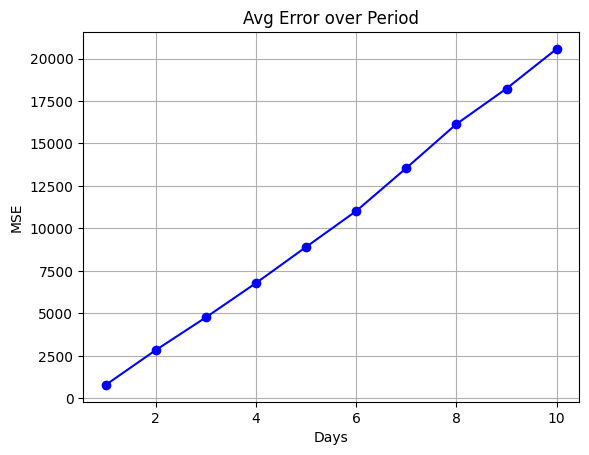

In [43]:
values = mse_list

# Create x-values starting from 1
x = list(range(1, len(values) + 1))

# Plot the line graph
plt.plot(x, values, marker='o', linestyle='-', color='b')
plt.xlabel('Days')
plt.ylabel('MSE')
plt.title('Avg Error over Period')
plt.grid(True)
plt.show()

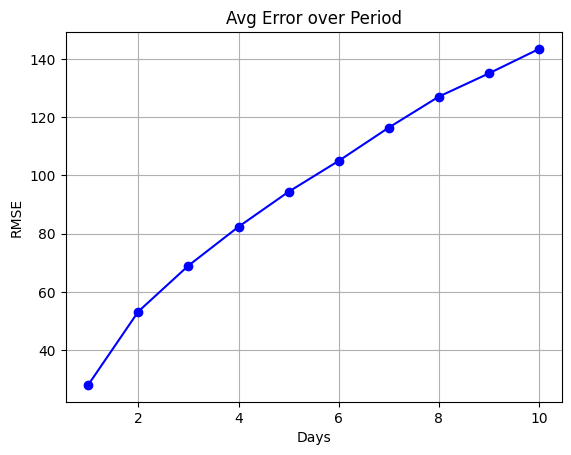

In [45]:
values = rmse_list

# Create x-values starting from 1
x = list(range(1, len(values) + 1))

# Plot the line graph
plt.plot(x, values, marker='o', linestyle='-', color='b')
plt.xlabel('Days')
plt.ylabel('RMSE')
plt.title('Avg Error over Period')
plt.grid(True)
plt.show()

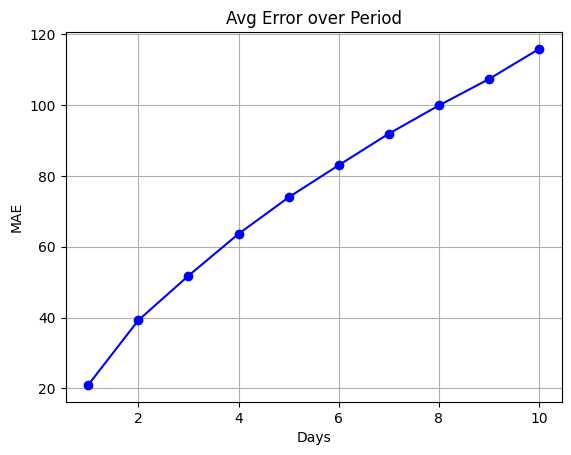

In [46]:
values = mae_list

# Create x-values starting from 1
x = list(range(1, len(values) + 1))

# Plot the line graph
plt.plot(x, values, marker='o', linestyle='-', color='b')
plt.xlabel('Days')
plt.ylabel('MAE')
plt.title('Avg Error over Period')
plt.grid(True)
plt.show()

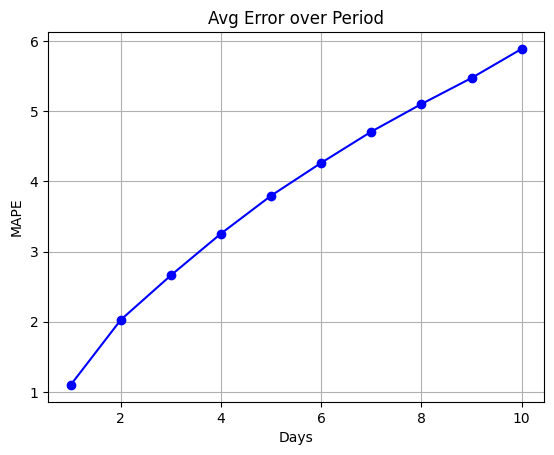

In [49]:
values = [x*100 for x in mape_list]

# Create x-values starting from 1
x = list(range(1, len(values) + 1))

# Plot the line graph
plt.plot(x, values, marker='o', linestyle='-', color='b')
plt.xlabel('Days')
plt.ylabel('MAPE')
plt.title('Avg Error over Period')
plt.grid(True)
plt.show()

In [51]:
from mlflow.tracking import MlflowClient
from mlflow.entities import Metric

client = MlflowClient()
run_id = "9cf306f37a82408c87a14f40118b0fae"

for i in range(len(mse_list)):
    client.log_metric(run_id, key="mse_daily", value=mse_list[i], step=(i+1))
    client.log_metric(run_id, key="rmse_daily", value=rmse_list[i], step=(i+1))
    client.log_metric(run_id, key="mae_daily", value=mae_list[i], step=(i+1))
    client.log_metric(run_id, key="mape_daily", value=mape_list[i], step=(i+1))